## ⚙️ Model Güncellemesi

Modele import edilen ekonomik değişkenler, model çıktısında oluşan ufak bir hata nedeniyle önceki versiyonda modele dahil edilmemiştir. Bu sorun tespit edilerek düzeltilmiş ve ekonomik değişkenler modele doğru şekilde entegre edilmiştir.

---

## 📊 Model Performansı (Güncel)

| Metrik | Değer |
|-------|------|
| R² | 0.9205 |
| MAE | 243,855.01 |
| RMSE | 581,222.27 |
| SMAPE | 21.02% |
| WAPE | 21.82% |

---

## 🔄 Tahmin Değişim Analizi

- Toplam **232 tahmin satırının tamamı güncellenmiştir.**

### 📈 Fark İstatistikleri

| Ölçüt | Değer |
|------|------|
| Ortalama Mutlak Fark | 32,846 ton |
| Medyan Mutlak Fark | 16,506 ton |
| Maksimum Fark | 264,340 ton |
| Ortalama Yüzde Fark | %5.94 |

---

## 🧠 Kısa Yorum

- Model güncellemesi sonrası tüm tahminlerin değiştiği gözlemlenmiştir.  
- Ortalama fark seviyesinin düşük kalması (%5.94), model davranışının genel olarak stabil olduğunu göstermektedir.  
- Ancak bazı uç değerlerde (maksimum fark) belirgin sapmalar bulunmaktadır.

In [1]:

# ============================================================
# ASAMA 1 - BASLANGIC
# ============================================================

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

GERCEK_LABEL = "Ger\u00e7ek"
TAHIL_LABEL = "Tah\u0131l"


def find_data_dir():
    """Find the repo data directory regardless of the notebook working directory."""
    current = Path.cwd().resolve()
    for base in [current, *current.parents]:
        candidate = base / "veri"
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Repo veri klasoru bulunamadi.")


def pick_data_file(pattern):
    matches = sorted(DATA_DIR.glob(pattern))
    if not matches:
        raise FileNotFoundError(f"Veri dosyasi bulunamadi: {pattern}")
    return matches[0]


DATA_DIR = find_data_dir()
REPO_ROOT = DATA_DIR.parent
MODEL_DIR = REPO_ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

PATH_MEYVE = DATA_DIR / "tuketim_meyve.xlsx"
PATH_SEBZE = DATA_DIR / "tuketim_sebze.xlsx"
PATH_TAHIL = DATA_DIR / "tuketim_tahil.xlsx"
PATH_NUFUS = pick_data_file("Nufus*.xlsx")
PATH_ENDEKS = DATA_DIR / "Endeks_Verileri_2014_2024.xlsx"
PATH_GELIR = pick_data_file("*Hanehalk*.xlsx")

print("Calisma klasoru:", os.getcwd())
print("Veri klasoru:", DATA_DIR)
print("Model cikti klasoru:", MODEL_DIR)

print("\nDosya kontrolu:")
for p in [PATH_MEYVE, PATH_SEBZE, PATH_TAHIL, PATH_NUFUS, PATH_ENDEKS, PATH_GELIR]:
    print(p.name, "->", "VAR" if p.exists() else "YOK")



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\Ali\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\Ali\anaconda3\Lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\Ali\anaconda3\Lib\site-packages\ipykernel\kernelapp.py", line 701, in start
    self.io_loop.start()
  File "C:\Users\Ali\AppData\Roaming\Python\Python31

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Calisma klasoru: c:\Users\Ali\Documents\GitHub\tarimpro\models
Veri klasoru: C:\Users\Ali\Documents\GitHub\tarimpro\veri
Model cikti klasoru: C:\Users\Ali\Documents\GitHub\tarimpro\models

Dosya kontrolu:
tuketim_meyve.xlsx -> VAR
tuketim_sebze.xlsx -> VAR
tuketim_tahil.xlsx -> VAR
Nufus (1).xlsx -> VAR
Endeks_Verileri_2014_2024.xlsx -> VAR
Yıllık Hanehalkı Kullanılabilir Gelirin Dağılımı (Ortalama, Tl) (1).xlsx -> VAR


In [25]:

# ============================================================
# ASAMA 2 - VERI OKUMA
# ============================================================

meyve = pd.read_excel(PATH_MEYVE)
sebze = pd.read_excel(PATH_SEBZE)
tahil = pd.read_excel(PATH_TAHIL)

nufus = pd.read_excel(PATH_NUFUS, header=1)
endeks = pd.read_excel(PATH_ENDEKS)
gelir = pd.read_excel(PATH_GELIR)

print("MEYVE:", meyve.shape)
print("SEBZE:", sebze.shape)
print("TAHIL:", tahil.shape)
print("NUFUS:", nufus.shape)
print("ENDEKS:", endeks.shape)
print("GELIR:", gelir.shape)


MEYVE: (230, 5)
SEBZE: (210, 5)
TAHIL: (140, 5)
NUFUS: (11, 5)
ENDEKS: (11, 13)
GELIR: (27, 4)


In [26]:

# ============================================================
# ASAMA 3 - TUKETIM VERISI
# ============================================================

meyve["Ana_Kategori"] = "Meyve"
sebze["Ana_Kategori"] = "Sebze"
tahil["Ana_Kategori"] = "Tahil"

tuketim = pd.concat([meyve, sebze, tahil], ignore_index=True)

tuketim = tuketim.rename(columns={
    "Urun Adi": "Urun_Adi",
    "Deger": "Tuketim"
})

tuketim = tuketim[["Yil", "Urun_Adi", "Tuketim", "Ana_Kategori"]]

print("TUKETIM SHAPE:", tuketim.shape)

print("\nYillara gore satir sayisi:")
print(tuketim.groupby("Yil").size())

tuketim.head()


TUKETIM SHAPE: (580, 4)

Yillara gore satir sayisi:
Yil
2014    58
2015    58
2016    58
2017    58
2018    58
2019    58
2020    58
2021    58
2022    58
2023    58
dtype: int64


,Yil,Urun_Adi,Tuketim,Ana_Kategori
0,2014,Üzüm,2312472,Meyve
1,2015,Üzüm,2071782,Meyve
2,2016,Üzüm,2287528,Meyve
3,2017,Üzüm,2186118,Meyve
4,2018,Üzüm,2180670,Meyve


In [4]:

# ============================================================
# ASAMA 4 - NUFUS
# ============================================================

# In the source file, the first column is year and the third column is total population.
nufus = nufus.iloc[:, [0, 2]].copy()
nufus.columns = ["Yil", "Nufus"]

nufus["Yil"] = pd.to_numeric(nufus["Yil"], errors="coerce")
nufus["Nufus"] = pd.to_numeric(nufus["Nufus"], errors="coerce")
nufus = nufus.dropna().copy()
nufus["Yil"] = nufus["Yil"].astype(int)

print(nufus)


     Yil     Nufus
0   2024  85664944
1   2023  85372377
2   2022  85279553
3   2021  84680273
4   2020  83614362
5   2019  83154997
6   2018  82003882
7   2017  80810525
8   2016  79814871
9   2015  78741053
10  2014  77695904


In [5]:

# ============================================================
# ASAMA 5 - ENDEKS
# ============================================================

# Annual index is calculated as the average of monthly index values.
endeks = pd.DataFrame({
    "Yil": pd.to_numeric(endeks.iloc[:, 0], errors="coerce"),
    "Endeks_Ortalama": endeks.iloc[:, 1:].apply(pd.to_numeric, errors="coerce").mean(axis=1),
})

endeks = endeks.dropna().copy()
endeks["Yil"] = endeks["Yil"].astype(int)

print(endeks)


     Yil  Endeks_Ortalama
0   2024      2360.025000
1   2023      1488.914167
2   2022       967.710833
3   2021       561.614167
4   2020       469.590833
5   2019       418.235833
6   2018       363.125000
7   2017       312.144167
8   2016       280.845833
9   2015       260.585000
10  2014       242.020000


In [6]:

# ============================================================
# ASAMA 6 - GELIR
# ============================================================

gelir = gelir.iloc[3:, [2, 3]].copy()
gelir.columns = ["Yil", "Hanehalki_Gelir"]

gelir["Yil"] = pd.to_numeric(gelir["Yil"], errors="coerce")
gelir["Hanehalki_Gelir"] = pd.to_numeric(gelir["Hanehalki_Gelir"], errors="coerce")
gelir = gelir.dropna().copy()
gelir["Yil"] = gelir["Yil"].astype(int)

# Some files contain multiple income types for the same year; use yearly average.
gelir = gelir.groupby("Yil", as_index=False)["Hanehalki_Gelir"].mean()

print(gelir)


     Yil  Hanehalki_Gelir
0   2014          23276.5
1   2015          26277.0
2   2016          30269.0
3   2017          33854.0
4   2018          37786.5
5   2019          44197.5
6   2020          51388.5
7   2021          57066.5
8   2022          73529.0
9   2023         135658.0
10  2024         281313.5
11  2025         497648.0


In [7]:

# ============================================================
# ASAMA 7 - DATASET
# ============================================================

data = tuketim.merge(nufus, on="Yil", how="left")
data = data.merge(endeks, on="Yil", how="left")
data = data.merge(gelir, on="Yil", how="left")

print("DATA SHAPE:", data.shape)

print("\nYillara gore satir sayisi:")
print(data.groupby("Yil").size())

data.head()


DATA SHAPE: (580, 7)

Yillara gore satir sayisi:
Yil
2014    58
2015    58
2016    58
2017    58
2018    58
2019    58
2020    58
2021    58
2022    58
2023    58
dtype: int64


,Yil,Urun_Adi,Tuketim,Ana_Kategori,Nufus,Endeks_Ortalama,Hanehalki_Gelir
0,2014,Üzüm,2312472,Meyve,77695904,242.020000,23276.5
1,2015,Üzüm,2071782,Meyve,78741053,260.585000,26277.0
2,2016,Üzüm,2287528,Meyve,79814871,280.845833,30269.0
3,2017,Üzüm,2186118,Meyve,80810525,312.144167,33854.0
4,2018,Üzüm,2180670,Meyve,82003882,363.125000,37786.5


In [8]:

# ============================================================
# ASAMA 8 - FEATURE ENGINEERING
# ============================================================

df = data.copy()

df = df.sort_values(["Urun_Adi", "Yil"]).reset_index(drop=True)

grp = df.groupby("Urun_Adi", group_keys=False)

# Previous-year consumption.
df["Lag1"] = grp["Tuketim"].shift(1)

# Product-level trailing 3-year mean. transform prevents cross-product rolling leakage.
df["RollingMean3"] = grp["Tuketim"].transform(lambda s: s.shift(1).rolling(3).mean())

# Log transforms.
df["Lag1_log"] = np.log1p(df["Lag1"])
df["RollingMean3_log"] = np.log1p(df["RollingMean3"])

# Time trend.
df["Trend"] = df["Yil"] - df["Yil"].min()

print("Feature dataset shape:", df.shape)

print("\nEksik degerler:")
print(df[["Lag1", "RollingMean3", "Nufus", "Endeks_Ortalama", "Hanehalki_Gelir"]].isna().sum())

print("\nOrnek veri:")
display(df.head(10))


Feature dataset shape: (580, 12)

Eksik degerler:
Lag1                58
RollingMean3       174
Nufus                0
Endeks_Ortalama      0
Hanehalki_Gelir      0
dtype: int64

Ornek veri:


,Yil,Urun_Adi,Tuketim,Ana_Kategori,Nufus,Endeks_Ortalama,Hanehalki_Gelir,Lag1,RollingMean3,Lag1_log,RollingMean3_log,Trend
0,2014,Antep Fıstığı,70158,Meyve,77695904,242.020000,23276.5,NaN,NaN,NaN,NaN,0
1,2015,Antep Fıstığı,121566,Meyve,78741053,260.585000,26277.0,70158.0,NaN,11.158519,NaN,1
2,2016,Antep Fıstığı,147037,Meyve,79814871,280.845833,30269.0,121566.0,NaN,11.708221,NaN,2
3,2017,Antep Fıstığı,66905,Meyve,80810525,312.144167,33854.0,147037.0,112920.333333,11.898446,11.634447,3
4,2018,Antep Fıstığı,205743,Meyve,82003882,363.125000,37786.5,66905.0,111836.000000,11.111044,11.624798,4
5,2019,Antep Fıstığı,68244,Meyve,83154997,418.235833,44197.5,205743.0,139895.000000,12.234388,11.848655,5
6,2020,Antep Fıstığı,247947,Meyve,83614362,469.590833,51388.5,68244.0,113630.666667,11.130859,11.640718,6
7,2021,Antep Fıstığı,71607,Meyve,84680273,561.614167,57066.5,247947.0,173978.000000,12.420974,12.066690,7
8,2022,Antep Fıstığı,217292,Meyve,85279553,967.710833,73529.0,71607.0,129266.000000,11.178962,11.769635,8
9,2023,Antep Fıstığı,149251,Meyve,85372377,1488.914167,135658.0,217292.0,178948.666667,12.289002,12.094860,9


In [9]:

# ============================================================
# ASAMA 9 - MODEL DATASET
# ============================================================

model_df = df.dropna().copy()

print("Model dataset shape:", model_df.shape)

print("\nYil araligi:")
print(model_df["Yil"].min(), "-", model_df["Yil"].max())

print("\nKategori bazinda urun sayisi:")
print(model_df.groupby("Ana_Kategori")["Urun_Adi"].nunique())

print("\nOrnek veri:")
display(model_df.head(10))


Model dataset shape: (406, 12)

Yil araligi:
2017 - 2023

Kategori bazinda urun sayisi:
Ana_Kategori
Meyve    23
Sebze    21
Tahil    14
Name: Urun_Adi, dtype: int64

Ornek veri:


,Yil,Urun_Adi,Tuketim,Ana_Kategori,Nufus,Endeks_Ortalama,Hanehalki_Gelir,Lag1,RollingMean3,Lag1_log,RollingMean3_log,Trend
3,2017,Antep Fıstığı,66905,Meyve,80810525,312.144167,33854.0,147037.0,112920.333333,11.898446,11.634447,3
4,2018,Antep Fıstığı,205743,Meyve,82003882,363.125000,37786.5,66905.0,111836.000000,11.111044,11.624798,4
5,2019,Antep Fıstığı,68244,Meyve,83154997,418.235833,44197.5,205743.0,139895.000000,12.234388,11.848655,5
6,2020,Antep Fıstığı,247947,Meyve,83614362,469.590833,51388.5,68244.0,113630.666667,11.130859,11.640718,6
7,2021,Antep Fıstığı,71607,Meyve,84680273,561.614167,57066.5,247947.0,173978.000000,12.420974,12.066690,7
8,2022,Antep Fıstığı,217292,Meyve,85279553,967.710833,73529.0,71607.0,129266.000000,11.178962,11.769635,8
9,2023,Antep Fıstığı,149251,Meyve,85372377,1488.914167,135658.0,217292.0,178948.666667,12.289002,12.094860,9
13,2017,Armut,395523,Meyve,80810525,312.144167,33854.0,391336.0,382730.000000,12.877324,12.855088,3
14,2018,Armut,417867,Meyve,82003882,363.125000,37786.5,395523.0,387660.666667,12.887967,12.867888,4
15,2019,Armut,411742,Meyve,83154997,418.235833,44197.5,417867.0,401575.333333,12.942921,12.903153,5


In [10]:

# ============================================================
# ASAMA 10 - TRAIN TEST
# ============================================================

train_df = model_df[model_df["Yil"] < 2023]
test_df = model_df[model_df["Yil"] == 2023]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain yillari:", sorted(train_df["Yil"].unique()))
print("Test yili:", sorted(test_df["Yil"].unique()))


Train shape: (348, 12)
Test shape: (58, 12)

Train yillari: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Test yili: [np.int64(2023)]


In [11]:

# ============================================================
# ASAMA 11 - MODEL
# ============================================================

FEATURES_NUM = [
    "Lag1_log",
    "RollingMean3_log",
    "Trend",
    "Nufus",
    "Endeks_Ortalama",
    "Hanehalki_Gelir",
]

FEATURES_CAT = [
    "Urun_Adi",
]

TARGET = "Tuketim"


def _wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100)


def _smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    out = np.zeros_like(y_true, dtype=float)
    out[mask] = 2 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask]
    return float(np.mean(out) * 100)


def build_model(alpha):
    preprocess = ColumnTransformer([
        ("num", StandardScaler(), FEATURES_NUM),
        ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
    ])
    return Pipeline([
        ("prep", preprocess),
        ("model", Ridge(alpha=alpha)),
    ])


# Hyperparameter is selected on earlier validation years, not on the final 2023 holdout.
alpha_candidates = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
validation_years = [2020, 2021, 2022]
alpha_rows = []

for alpha in alpha_candidates:
    fold_scores = []
    for validation_year in validation_years:
        fold_train = model_df[model_df["Yil"] < validation_year]
        fold_valid = model_df[model_df["Yil"] == validation_year]
        if len(fold_train) == 0 or len(fold_valid) == 0:
            continue

        candidate_model = build_model(alpha)
        candidate_model.fit(fold_train[FEATURES_NUM + FEATURES_CAT], np.log1p(fold_train[TARGET]))
        fold_pred = np.expm1(candidate_model.predict(fold_valid[FEATURES_NUM + FEATURES_CAT]))
        fold_scores.append({
            "validation_year": validation_year,
            "WAPE_%": _wape(fold_valid[TARGET], fold_pred),
            "SMAPE_%": _smape(fold_valid[TARGET], fold_pred),
            "R2": r2_score(fold_valid[TARGET], fold_pred),
        })

    if fold_scores:
        alpha_rows.append({
            "alpha": alpha,
            "mean_WAPE_%": float(np.mean([row["WAPE_%"] for row in fold_scores])),
            "mean_SMAPE_%": float(np.mean([row["SMAPE_%"] for row in fold_scores])),
            "mean_R2": float(np.mean([row["R2"] for row in fold_scores])),
        })

alpha_summary = pd.DataFrame(alpha_rows).sort_values(["mean_WAPE_%", "mean_SMAPE_%"]).reset_index(drop=True)
RIDGE_ALPHA = float(alpha_summary.iloc[0]["alpha"]) if len(alpha_summary) else 10.0

print("Secilen Ridge alpha:", RIDGE_ALPHA)
display(alpha_summary)

model = build_model(RIDGE_ALPHA)


Secilen Ridge alpha: 10.0


,alpha,mean_WAPE_%,mean_SMAPE_%,mean_R2
0,10.00,9.315635,13.214091,0.989847
1,1.00,12.476356,17.395567,0.980283
2,0.01,14.544756,18.648383,0.973405
3,0.10,17.062657,22.337710,0.956900
4,100.00,32.518293,24.549761,0.763026
5,1000.00,73.506727,74.463469,0.046826


In [12]:

# ============================================================
# ASAMA 12 - MODEL EGIT
# ============================================================

X_train = train_df[FEATURES_NUM + FEATURES_CAT]
y_train = np.log1p(train_df[TARGET])

X_test = test_df[FEATURES_NUM + FEATURES_CAT]
y_test = test_df[TARGET]

model.fit(X_train, y_train)

pred_log = model.predict(X_test)
pred = np.expm1(pred_log)


def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    out = np.zeros_like(y_true, dtype=float)
    out[mask] = 2 * np.abs(y_pred[mask] - y_true[mask]) / denom[mask]
    return float(np.mean(out) * 100)


def wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100)


print("R2:", round(r2_score(y_test, pred), 4))
print("MAE:", round(mean_absolute_error(y_test, pred), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, pred)), 2))
print("SMAPE:", round(smape(y_test, pred), 2))
print("WAPE:", round(wape(y_test, pred), 2))


R2: 0.9205
MAE: 243855.01
RMSE: 581222.27
SMAPE: 21.02
WAPE: 21.82


In [13]:

# ============================================================
# ASAMA 13 - MAKRO VERILER
# ============================================================

macro = nufus.merge(endeks, on="Yil", how="outer").merge(gelir, on="Yil", how="outer")
macro = macro.sort_values("Yil").reset_index(drop=True)

origin_year = 2023
future_years = [2024, 2025, 2026, 2027]

# Macro projections use only data available up to 2023 to avoid look-ahead leakage.
historical_macro = macro[macro["Yil"] <= origin_year].dropna(
    subset=["Nufus", "Endeks_Ortalama", "Hanehalki_Gelir"]
).copy()

macro_future = historical_macro.copy()

for col in ["Nufus", "Endeks_Ortalama", "Hanehalki_Gelir"]:
    lr = LinearRegression()
    lr.fit(historical_macro[["Yil"]], historical_macro[col])

    future_frame = pd.DataFrame({"Yil": future_years})
    future_values = lr.predict(future_frame[["Yil"]])

    for year, value in zip(future_years, future_values):
        if year not in macro_future["Yil"].values:
            macro_future = pd.concat([macro_future, pd.DataFrame({"Yil": [year]})], ignore_index=True)
        macro_future.loc[macro_future["Yil"] == year, col] = value

macro_future = macro_future.sort_values("Yil").reset_index(drop=True)

macro_future.tail(10)


,Yil,Nufus,Endeks_Ortalama,Hanehalki_Gelir
4,2018,8.200388e+07,363.125000,37786.500000
5,2019,8.315500e+07,418.235833,44197.500000
6,2020,8.361436e+07,469.590833,51388.500000
7,2021,8.468027e+07,561.614167,57066.500000
8,2022,8.527955e+07,967.710833,73529.000000
9,2023,8.537238e+07,1488.914167,135658.000000
10,2024,8.707503e+07,1139.919278,102503.566667
11,2025,8.797653e+07,1249.635768,111807.806061
12,2026,8.887802e+07,1359.352258,121112.045455
13,2027,8.977952e+07,1469.068747,130416.284848


In [14]:

# ============================================================
# ASAMA 14 - RECURSIVE FORECAST
# ============================================================

future_years = [2024, 2025, 2026, 2027]

predictions = []

for urun, g in df.groupby("Urun_Adi"):

    g = g.sort_values("Yil").copy()

    last_lag = float(g.iloc[-1]["Tuketim"])
    rolling = float(g["Tuketim"].tail(3).mean())

    for year in future_years:

        macro_row = macro_future.loc[macro_future["Yil"] == year].iloc[0]

        row = pd.DataFrame({
            "Lag1_log": [np.log1p(last_lag)],
            "RollingMean3_log": [np.log1p(rolling)],
            "Trend": [year - df["Yil"].min()],
            "Nufus": [macro_row["Nufus"]],
            "Endeks_Ortalama": [macro_row["Endeks_Ortalama"]],
            "Hanehalki_Gelir": [macro_row["Hanehalki_Gelir"]],
            "Urun_Adi": [urun],
        })

        pred_log = model.predict(row)[0]
        pred = np.expm1(pred_log)

        # Stabilizer.
        pred = 0.7 * pred + 0.3 * rolling

        # Conservative band to reduce extreme recursive jumps.
        pred = np.clip(pred, rolling * 0.5, rolling * 1.8)

        predictions.append({
            "Urun_Adi": urun,
            "Yil": year,
            "Tahmin_Tuketim": pred,
        })

        last_lag = pred
        rolling = (rolling * 2 + pred) / 3


pred_df = pd.DataFrame(predictions)

print(pred_df.shape)
pred_df.head(10)


(232, 3)


,Urun_Adi,Yil,Tahmin_Tuketim
0,Antep Fıstığı,2024,159993.094279
1,Antep Fıstığı,2025,168983.138266
2,Antep Fıstığı,2026,178244.522958
3,Antep Fıstığı,2027,188443.482181
4,Armut,2024,415741.299795
5,Armut,2025,433084.321649
6,Armut,2026,452150.793219
7,Armut,2027,473587.625619
8,Arpa,2024,86438.882808
9,Arpa,2025,89979.186660


In [15]:

# ============================================================
# ASAMA 15 - COMBINE
# ============================================================

real = df[["Yil", "Urun_Adi", "Tuketim"]].copy()
real["Tip"] = GERCEK_LABEL

pred_df["Tip"] = "Tahmin"
pred_df = pred_df.rename(columns={"Tahmin_Tuketim": "Tuketim"})

combined = pd.concat([real, pred_df])

combined.head()


,Yil,Urun_Adi,Tuketim,Tip
0,2014,Antep Fıstığı,70158.0,Gerçek
1,2015,Antep Fıstığı,121566.0,Gerçek
2,2016,Antep Fıstığı,147037.0,Gerçek
3,2017,Antep Fıstığı,66905.0,Gerçek
4,2018,Antep Fıstığı,205743.0,Gerçek


In [16]:
# ============================================================
# AŞAMA 16 — GRAFİKLER
# ============================================================

import os
import matplotlib.pyplot as plt

os.makedirs("grafiklerv3", exist_ok=True)

for urun, g in combined.groupby("Urun_Adi"):

    g = g.sort_values("Yil")

    real = g[g["Tip"]=="Gerçek"]
    pred = g[g["Tip"]=="Tahmin"]

    plt.figure(figsize=(8,4))

    plt.plot(real["Yil"], real["Tuketim"], marker="o", label="Gerçek")
    plt.plot(pred["Yil"], pred["Tuketim"], marker="o", label="Tahmin")

    plt.title(urun)
    plt.xlabel("Yıl")
    plt.ylabel("Tüketim")

    plt.legend()

    plt.tight_layout()

    plt.savefig(f"grafiklerv3/{urun}.png")

    plt.close()

print("Grafikler hazır.")

Grafikler hazır.


In [17]:
# ============================================================
# TÜM GRAFİKLER TEK PDF
# ============================================================

import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

pdf_path = "tuketim_grafikv3.pdf"

with PdfPages(pdf_path) as pdf:

    for urun, g in combined.groupby("Urun_Adi"):

        g = g.sort_values("Yil")

        real = g[g["Tip"]=="Gerçek"]
        pred = g[g["Tip"]=="Tahmin"]

        plt.figure(figsize=(10,5))

        plt.plot(real["Yil"], real["Tuketim"], marker="o", label="Gerçek")
        plt.plot(pred["Yil"], pred["Tuketim"], marker="o", linestyle="--", label="Tahmin")

        plt.title(f"{urun} Tüketim Tahmini (2014-2027)")
        plt.xlabel("Yıl")
        plt.ylabel("Tüketim (Ton)")

        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.tight_layout()

        pdf.savefig()
        plt.close()

print("PDF oluşturuldu:", pdf_path)

PDF oluşturuldu: tuketim_grafikv3.pdf


In [18]:

# ============================================================
# EXCEL CIKTISI
# ============================================================

# Standardize forecast column name.
pred_export = pred_df.copy()
pred_export = pred_export.rename(columns={"Tahmin_Tuketim": "Tuketim"})
pred_export["Tip"] = "Tahmin"

output_file = MODEL_DIR / "tuketim_tahminleri_2024_2027v3.xlsx"
combined_output_file = MODEL_DIR / "tuketim_ve_tahmin_birlesik.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    pred_export.sort_values(["Urun_Adi", "Yil"]).to_excel(
        writer,
        sheet_name="Tahminler",
        index=False,
    )

    df.sort_values(["Urun_Adi", "Yil"]).to_excel(
        writer,
        sheet_name="Gercek_Veriler",
        index=False,
    )

    combined.sort_values(["Urun_Adi", "Yil"]).to_excel(
        writer,
        sheet_name="Tum_Veriler",
        index=False,
    )

actual_sheets = []
for source_name, label in [
    ("tuketim_meyve.xlsx", "Meyve"),
    ("tuketim_sebze.xlsx", "Sebze"),
    ("tuketim_tahil.xlsx", TAHIL_LABEL),
]:
    actual = pd.read_excel(DATA_DIR / source_name).rename(columns={"Urun Adi": "Urun_Adi", "Deger": "Tuketim"})
    actual = actual[["Yil", "Urun_Adi", "Tuketim"]].copy()
    actual["Tip"] = GERCEK_LABEL
    actual["Kaynak"] = label
    actual_sheets.append((label, actual))

all_actual = pd.concat([sheet for _, sheet in actual_sheets], ignore_index=True)
gercek_birlesik = all_actual[["Yil", "Urun_Adi", "Tip", "Tuketim"]].copy()
gercek_tahmin_birlesik = pd.concat(
    [gercek_birlesik, pred_export[["Yil", "Urun_Adi", "Tip", "Tuketim"]]],
    ignore_index=True,
)

with pd.ExcelWriter(combined_output_file, engine="openpyxl") as writer:
    for sheet_label, actual in actual_sheets:
        sheet_name = {"Meyve": "Meyve_Gercek", "Sebze": "Sebze_Gercek", TAHIL_LABEL: "Tahil_Gercek"}[sheet_label]
        actual.sort_values(["Urun_Adi", "Yil"]).to_excel(writer, sheet_name=sheet_name, index=False)

    gercek_birlesik.sort_values(["Urun_Adi", "Yil"]).to_excel(writer, sheet_name="Gercek_Birlesik", index=False)
    pred_export[["Yil", "Urun_Adi", "Tuketim", "Tip"]].sort_values(["Urun_Adi", "Yil"]).to_excel(writer, sheet_name="Tahminler", index=False)
    combined.sort_values(["Urun_Adi", "Yil"]).to_excel(writer, sheet_name="Tahmin_Dosyasi_TumVeri", index=False)
    gercek_tahmin_birlesik.sort_values(["Urun_Adi", "Yil"]).to_excel(writer, sheet_name="Gercek_ve_Tahmin_Birlesik", index=False)

# The running application currently imports these files from veri/. Keep those synced without changing the primary model output folder.
for source_file in [output_file, combined_output_file]:
    target_file = DATA_DIR / source_file.name
    target_file.write_bytes(source_file.read_bytes())

print("Excel dosyalari models klasorune olusturuldu:")
print("-", output_file)
print("-", combined_output_file)
print("Uygulama veri kopyalari da senkron tutuldu:")
print("-", DATA_DIR / output_file.name)
print("-", DATA_DIR / combined_output_file.name)


Excel dosyalari models klasorune olusturuldu:
- C:\Users\Ali\Documents\GitHub\tarimpro\models\tuketim_tahminleri_2024_2027v3.xlsx
- C:\Users\Ali\Documents\GitHub\tarimpro\models\tuketim_ve_tahmin_birlesik.xlsx
Uygulama veri kopyalari da senkron tutuldu:
- C:\Users\Ali\Documents\GitHub\tarimpro\veri\tuketim_tahminleri_2024_2027v3.xlsx
- C:\Users\Ali\Documents\GitHub\tarimpro\veri\tuketim_ve_tahmin_birlesik.xlsx


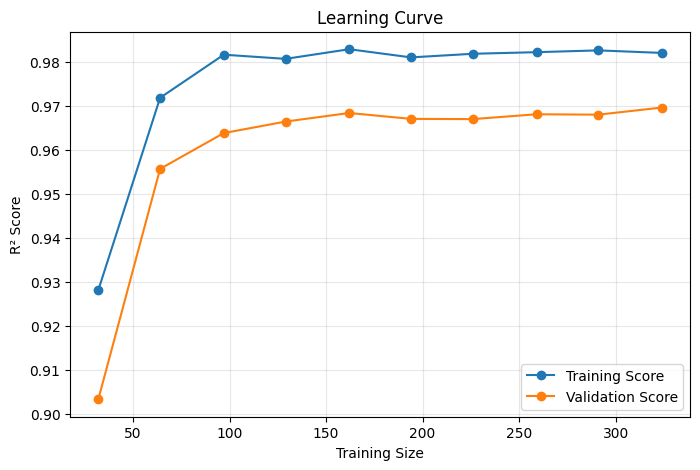

In [19]:
# ============================================================
# LEARNING CURVE
# ============================================================

from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

X_all = pd.concat([X_train, X_test])
y_all = np.log1p(pd.concat([train_df["Tuketim"], test_df["Tuketim"]]))

train_sizes, train_scores, val_scores = learning_curve(
    model,
    X_all,
    y_all,
    cv=5,
    scoring="r2",
    train_sizes=np.linspace(0.1,1.0,10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_mean, marker="o", label="Training Score")
plt.plot(train_sizes, val_mean, marker="o", label="Validation Score")

plt.title("Learning Curve")
plt.xlabel("Training Size")
plt.ylabel("R² Score")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

y_test boyutu : 58
pred boyutu   : 58


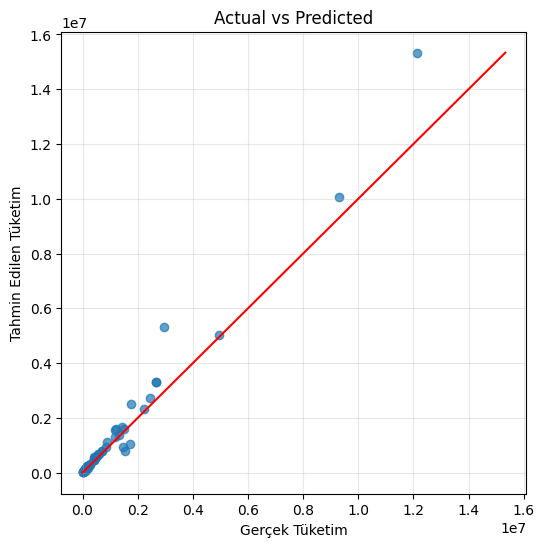

In [20]:
# ============================================================
# ACTUAL VS PREDICTED SCATTER
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Test tahminini yeniden üret
X_test_eval = test_df[FEATURES_NUM + FEATURES_CAT]
y_test_eval = test_df["Tuketim"].values

pred_log_eval = model.predict(X_test_eval)
pred_eval = np.expm1(pred_log_eval)

print("y_test boyutu :", len(y_test_eval))
print("pred boyutu   :", len(pred_eval))

plt.figure(figsize=(6,6))

plt.scatter(y_test_eval, pred_eval, alpha=0.7)

max_val = max(np.max(y_test_eval), np.max(pred_eval))
plt.plot([0, max_val], [0, max_val], color="red")

plt.xlabel("Gerçek Tüketim")
plt.ylabel("Tahmin Edilen Tüketim")
plt.title("Actual vs Predicted")
plt.grid(alpha=0.3)

plt.show()

Residual boyutu: 58


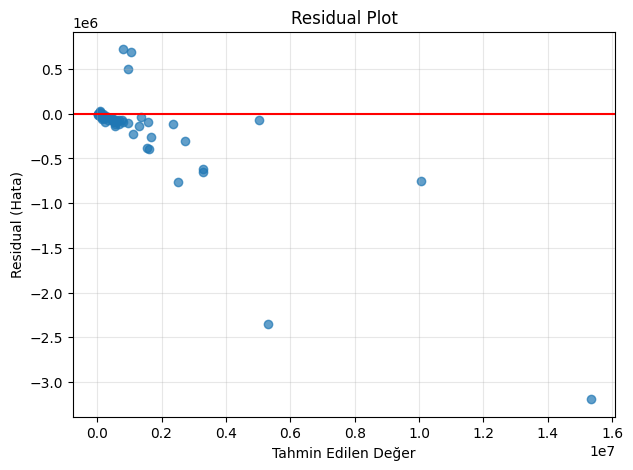

In [21]:
# ============================================================
# RESIDUAL PLOT
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Test tahminini yeniden üret
X_test_eval = test_df[FEATURES_NUM + FEATURES_CAT]
y_test_eval = test_df["Tuketim"].values

pred_log_eval = model.predict(X_test_eval)
pred_eval = np.expm1(pred_log_eval)

residuals = y_test_eval - pred_eval

print("Residual boyutu:", len(residuals))

plt.figure(figsize=(7,5))

plt.scatter(pred_eval, residuals, alpha=0.7)
plt.axhline(0, color="red")

plt.xlabel("Tahmin Edilen Değer")
plt.ylabel("Residual (Hata)")
plt.title("Residual Plot")
plt.grid(alpha=0.3)

plt.show()

X_test shape : (58, 7)
y_test shape : (58,)
pred shape   : (58,)


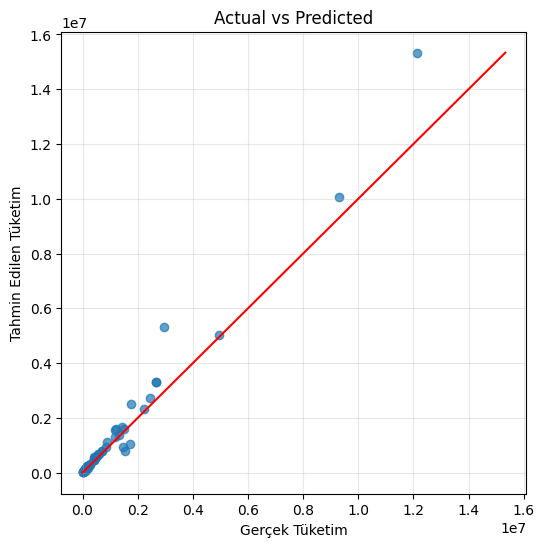

Residual shape: (58,)


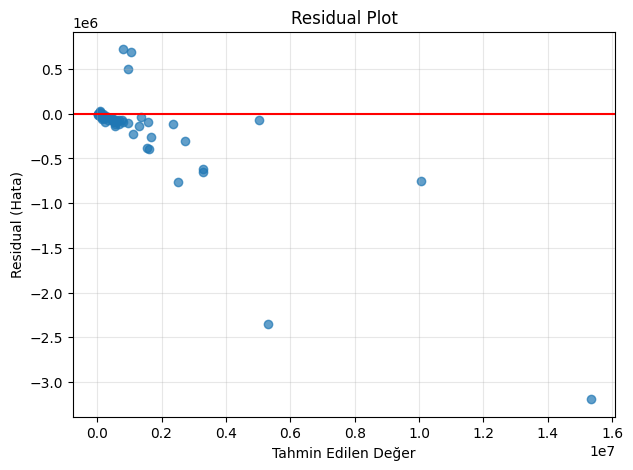

In [22]:
# ============================================================
# SHAPE + SCATTER + RESIDUAL
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# Test verisi
X_test_eval = test_df[FEATURES_NUM + FEATURES_CAT]
y_test_eval = test_df["Tuketim"].values

# Tahmin
pred_log_eval = model.predict(X_test_eval)
pred_eval = np.expm1(pred_log_eval)

# ============================================================
# SHAPE KONTROLÜ
# ============================================================

print("X_test shape :", X_test_eval.shape)
print("y_test shape :", y_test_eval.shape)
print("pred shape   :", pred_eval.shape)

# ============================================================
# SCATTER PLOT
# ============================================================

plt.figure(figsize=(6,6))

plt.scatter(y_test_eval, pred_eval, alpha=0.7)

max_val = max(np.max(y_test_eval), np.max(pred_eval))

plt.plot([0,max_val],[0,max_val], color="red")

plt.xlabel("Gerçek Tüketim")
plt.ylabel("Tahmin Edilen Tüketim")
plt.title("Actual vs Predicted")

plt.grid(alpha=0.3)

plt.show()

# ============================================================
# RESIDUAL PLOT
# ============================================================

residuals = y_test_eval - pred_eval

print("Residual shape:", residuals.shape)

plt.figure(figsize=(7,5))

plt.scatter(pred_eval, residuals, alpha=0.7)

plt.axhline(0, color="red")

plt.xlabel("Tahmin Edilen Değer")
plt.ylabel("Residual (Hata)")

plt.title("Residual Plot")

plt.grid(alpha=0.3)

plt.show()

X_transformed shape: (200, 64)
Feature name sayısı: 64


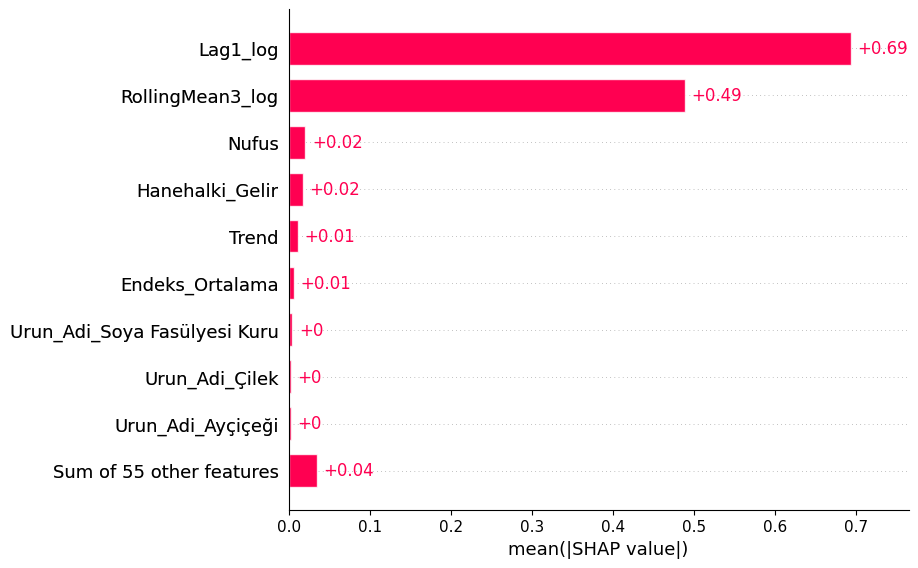

In [23]:
# ============================================================
# SHAP ANALİZİ (DÜZELTİLMİŞ)
# ============================================================

import shap
import pandas as pd
import numpy as np

# örnek veri
X_sample = X_train.sample(min(200, len(X_train)), random_state=42)

# preprocessing sonrası matris
X_transformed = model.named_steps["prep"].transform(X_sample)

# sparse ise dense'e çevir
if hasattr(X_transformed, "toarray"):
    X_transformed = X_transformed.toarray()

# feature isimleri
num_features = FEATURES_NUM
cat_encoder = model.named_steps["prep"].named_transformers_["cat"]
cat_features = cat_encoder.get_feature_names_out(FEATURES_CAT)
feature_names = list(num_features) + list(cat_features)

print("X_transformed shape:", X_transformed.shape)
print("Feature name sayısı:", len(feature_names))

# dataframe
X_transformed_df = pd.DataFrame(X_transformed, columns=feature_names)

# ridge modeli
ridge_model = model.named_steps["model"]

# shap
explainer = shap.Explainer(ridge_model, X_transformed_df)
shap_values = explainer(X_transformed_df)

# önem grafiği
shap.plots.bar(shap_values)

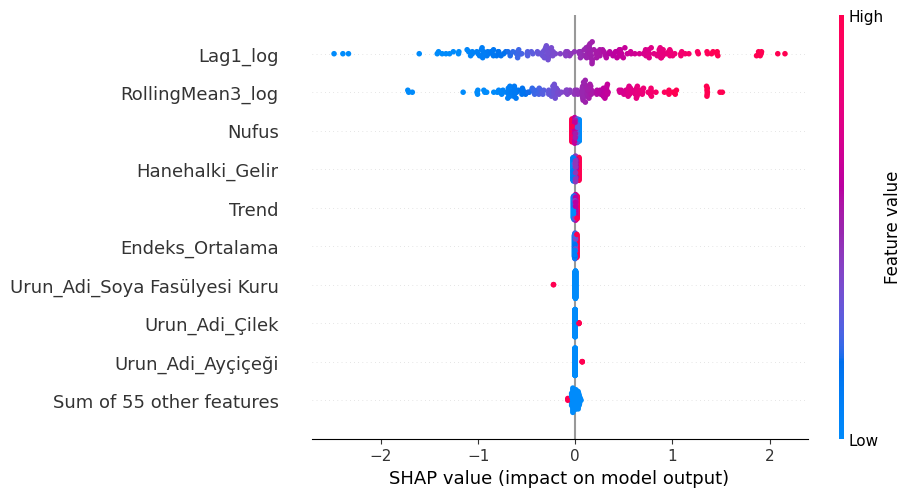

In [24]:
shap.plots.beeswarm(shap_values)